<a href="https://colab.research.google.com/github/maibamrakeshsingh/Graph-Neural-Networks-in-Molecular-Structure-Analysis/blob/main/Python%20Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Graph Neural Networks in Molecular Structure**

Graph‑structured data is central to domains like chemistry, biology, social networks, and knowledge graphs. Unlike tabular data, graphs capture both node features and relationships, enabling richer modeling. Graph Neural Networks (GNNs) leverage this structure through message passing, allowing information to flow along edges and updating node representations based on neighbors. This makes them effective for tasks such as molecular property prediction, where structural dependencies matter.

However, GNNs often act as black boxes, with predictions driven by complex substructures and feature interactions that are hard to interpret. In chemistry, interpretability is crucial to confirm whether models learn meaningful motifs, such as aromatic rings or mutagenic groups rather than dataset artifacts. Understanding why a GNN predicts mutagenicity is essential for scientific insight and trustworthy decision‑making.

To address this, the lab uses **GNNExplainer**, a framework that highlights the subgraphs and node features most influential in a model’s output. Working with the MUTAG dataset, you will train a Graph Convolutional Network (GCN) and apply GNNExplainer to uncover which molecular substructures drive predictions. By visualizing important atoms, bonds, and subgraphs, you will gain insight into how GNNs process chemical information and how explainability enhances transparency in graph learning.


**Objectives of the project**

- Represent molecular graphs using nodes (atoms) and edges (chemical bonds).  
- Train a Graph Convolutional Network (GCN) in PyTorch Geometric for mutagenicity classification on the MUTAG dataset.  
- Apply GNNExplainer to uncover influential substructures driving GNN predictions.  
- Visualize and evaluate explanation quality through important subgraphs, atoms, bonds, and fidelity/sparsity metrics.

**Graph Neural Networks (GNNs)**

Graph Neural Networks (GNNs) learn from graph‑structured data, where nodes represent entities and edges represent relationships. Using **message passing**, each node updates its representation by aggregating information from its neighbors, enabling the model to capture both local and relational patterns efficiently.

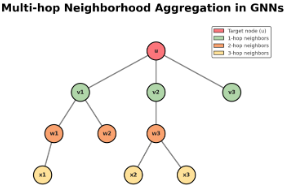


Figure 1. Multi‑hop neighborhood aggregation in GNNs: the target node \(u\) updates its representation by combining features from its 1‑hop (green), 2‑hop (orange), and 3‑hop (yellow) neighbors, enabling higher‑order information flow across the graph.


In GNNs, each node updates its representation by aggregating information from its neighbors using a permutation‑invariant operator (e.g., mean, sum, max). This captures both structural and relational context within the graph.  

Graph Convolutional Networks (GCNs) extend this idea by propagating information with a symmetrically normalized adjacency matrix. Self‑loops ensure nodes include their own features, while normalization prevents high‑degree nodes from dominating.  

The update rule combines neighbor aggregation, linear transformation, and nonlinear activation, enabling stable training and expressive learning. This framework naturally applies to molecular graphs, where atoms and bonds form structured relational data.

**Molecular Graphs**

Molecules can be represented as **graphs**, with nodes as atoms (carrying properties like atomic number, valence, and aromaticity) and edges as chemical bonds (single, double, or aromatic). This structure allows GNNs to model how electronic and functional relationships propagate across the molecule.

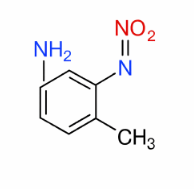


Figure 2. A simple molecular graph showing atoms as nodes and bonds as edges, illustrating how chemical structures map naturally to graph representations.


In the MUTAG dataset, several functional groups play key roles in mutagenicity classification, including NO₂ (nitro) groups, NH₂ (amino) groups, and aromatic rings, all of which strongly influence electron distribution and chemical reactivity.

**GNNExplainer**

GNNExplainer provides local explanations by identifying a subgraph and key node features that most influence a model’s prediction. This highlights the specific atoms, bonds, and feature dimensions driving the decision.

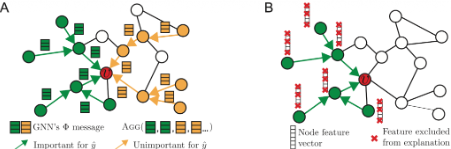

Figure 3. Overview of the GNNExplainer framework (adapted from Ying et al., 2019, NeurIPS). The explainer learns continuous masks over edges and node features, revealing which message-passing pathways and atomic attributes most strongly influence the GNN’s prediction. The resulting explanation subgraph highlights the functional groups and structural regions responsible for the model’s decision.

**Optimization Objective**

GNNExplainer addresses the question: *What is the smallest subgraph that still leads the model to make the same prediction?* It formalizes this by maximizing the mutual information between the model’s prediction and a compact explanation subgraph, ensuring that the explanation preserves confidence while remaining minimal.  

To make this objective differentiable, GNNExplainer introduces a continuous edge mask, where each edge is assigned an importance score. Applying this mask to the adjacency matrix produces a masked graph, allowing edge importance to be learned through gradient‑based optimization.  

The training loss balances fidelity with simplicity. Fidelity ensures the masked graph preserves the original prediction, sparsity encourages compact subgraphs, and entropy regularization pushes mask values toward crisp, interpretable decisions. Together, these terms yield faithful and parsimonious explanations.  

After optimization, thresholding the learned mask produces the final explanation subgraph. This subgraph highlights the most influential structural components while discarding irrelevant edges, making the explanation both accurate and interpretable.  

GNNExplainer learns two complementary masks: an edge mask that identifies key bonds and a feature mask that highlights important atomic properties. For molecular tasks, edge masks often provide the clearest insights, directly revealing chemical motifs and functional groups driving predictions.  

A faithful explanation means the model makes nearly the same prediction using only the explanation subgraph. By pruning low‑importance edges, fidelity curves can be generated to track confidence changes. In the MUTAG dataset, minimal faithful subgraphs often correspond to mutagenic motifs like nitro groups on aromatic rings, providing chemically meaningful interpretations of GNN decisions.

**Experiments**

**Installing Libraries**

In this first step, you will install all required libraries for graph learning and explainability. We install PyTorch, PyTorch Geometric (PyG), and supporting utilities for visualization and data processing. PyG is essential for loading the MUTAG dataset, defining GCN layers, and running GNNExplainer.

All necessary Python libraries for the project, including PyTorch, PyG, NumPy, NetworkX, and plotting utilities. We also configure deterministic behavior by setting seeds for PyTorch, NumPy, and Python’s random module. Reproducibility is crucial when working with GNNExplainer because explanation masks depend on random initialization. This cell also prints environment information so you can verify library versions.

In [ ]:
%pip -q install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu --index-url https://download.pytorch.org/whl/cpu
%pip -q install torch_geometric==2.6.1 matplotlib networkx scikit-learn pandas

print("✅ Dependencies installed (you may restart the kernel if needed).")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 60.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.1 MB/s eta 0:00:00
✅ Dependencies installed (you may restart the kernel if needed).


In [ ]:
# === Imports & Setup ===
import os, sys, random, shutil, math, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
import torch_geometric as tg
import urllib.request

from collections import Counter
from copy import deepcopy
from sklearn.model_selection import StratifiedShuffleSplit
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GINConv, global_mean_pool
from torch_geometric.explain import Explainer, GNNExplainer, ModelConfig
from torch_geometric.transforms import OneHotDegree

# Quiet noisy library warnings (optional)
warnings.filterwarnings("ignore", category=UserWarning, module="torch_geometric")
warnings.filterwarnings("ignore", category=FutureWarning, module="numpy")

# --- Reproducibility ---
SEED = 42

def seed_all(seed: int = 42) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    # These are harmless on CPU and good to have if CUDA is available
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Prefer deterministic kernels when available (avoid hard errors)
    torch.use_deterministic_algorithms(True, warn_only=True)

seed_all(SEED)

# Environment logs
device = torch.device("cpu")
print(f"Python {sys.version.split()[0]} | Torch {torch.__version__} | Device: {device}")

try:
    print(f"PyG {tg.__version__}")
except Exception:
    print("PyG <not imported yet>")

# Plotting defaults
plt.rcParams.update({"figure.dpi": 160})

Python 3.12.12 | Torch 2.8.0+cpu | Device: cpu
PyG 2.6.1


**MUTAG Dataset**

In this step, you download and prepare the MUTAG dataset for graph classification. MUTAG is a benchmark dataset of nitroaromatic molecules labeled as mutagenic or non-mutagenic. PyG automatically processes raw files into a list of molecular graphs. We display dataset statistics, including node feature dimensions and class distribution.

In [ ]:
# === Dataset ===

ROOT = Path(".")
RAW  = ROOT / "MUTAG" / "raw"
PROC = ROOT / "MUTAG" / "processed"
RAW.mkdir(parents=True, exist_ok=True)

# Map PyG expected filenames
LINKS = {
    "MUTAG_A.txt":                "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VZPVboZIsJoSA_faWDlg4A/MUTAG-A.txt",
    "MUTAG_graph_indicator.txt":  "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/3fwWJQrmgAvIgwWy-wjkbQ/MUTAG-graph-indicator.txt",
    "MUTAG_graph_labels.txt":     "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/O7WS_nB3E6ENBUlweKNErA/MUTAG-graph-labels.txt",
    "MUTAG_edge_labels.txt":      "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UcSey7kHPQHrz9edMNCD7Q/MUTAG-edge-labels.txt",
    "MUTAG_node_labels.txt":      "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GClYcRJLY7ZSqEpE_Rji8g/MUTAG-node-labels.txt",
    "README.txt":                 "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/B14QwXd6KwewJRG4TJF9_w/README.txt",
}

def fetch(src, dst):
    if dst.exists() and dst.stat().st_size > 0:
        return
    urllib.request.urlretrieve(src, dst)

# Download only if processed cache not present
if not PROC.exists():
    for fname, url in LINKS.items():
        fetch(url, RAW / fname)

# Load dataset (PyG reads raw/ and caches to processed/)
dataset = TUDataset(root=str(ROOT), name="MUTAG")
if dataset[0].x is None or dataset[0].x.dim() == 1:
    dataset = TUDataset(root=str(ROOT), name="MUTAG",
                        transform=OneHotDegree(max_degree=10))

# Quick summary
counts = Counter(int(d.y.item()) for d in dataset)
print(f"{dataset} | features: {dataset.num_features} | classes: {dataset.num_classes}")
print(f"Label counts: {dict(counts)}")


Processing...


MUTAG(188) | features: 7 | classes: 2
Label counts: {1: 125, 0: 63}


Done!


**Train–Validation Split and Data Loaders**

We create training and validation splits using stratified sampling to preserve class balance. Each molecule is treated as one graph-based example. PyG’s DataLoader batches graphs into mini-batches for efficient training. This cell builds the input pipeline that the GCN will use during training.

In [ ]:
# === Split & DataLoaders ===
TEST_SIZE = 0.20
BATCH_TRAIN = 32
BATCH_VAL   = 64

# Stratified 80/20 split
y_all = np.array([d.y.item() for d in dataset])
sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
train_idx, val_idx = next(sss.split(np.zeros_like(y_all), y_all))

train_ds = dataset[train_idx.tolist()]
val_ds   = dataset[val_idx.tolist()]

# Shuffle via seeded generator
gen = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_TRAIN,
    shuffle=True,
    generator=gen,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_VAL,
    shuffle=False,
)

print(f"Train/val sizes: {len(train_ds)} / {len(val_ds)} | "
      f"train: {dict(sorted(Counter(int(d.y.item()) for d in train_ds).items()))} | "
      f"val: {dict(sorted(Counter(int(d.y.item()) for d in val_ds).items()))}")


Train/val sizes: 150 / 38 | train: {0: 50, 1: 100} | val: {0: 13, 1: 25}


**Graph Convolutional Network (GCN)**

This cell defines the GCN architecture used for MUTAG graph-level prediction. The model consists of two graph convolution layers with batch normalization, ReLU activation, and dropout for regularization. A global mean pooling layer aggregates node embeddings into a graph-level representation. The final linear layer outputs logits for binary classification.  

This GCN will later be explained using GNNExplainer.

In [ ]:
class GCN(nn.Module):
    def __init__(self, in_dim, hidden=96, out_dim=2, p=0.2):
        super().__init__()
        # Block 1
        self.drop1 = nn.Dropout(p)
        self.conv1 = GCNConv(in_dim, hidden, improved=True)
        self.bn1   = nn.BatchNorm1d(hidden)
        # Block 2
        self.drop2 = nn.Dropout(p)
        self.conv2 = GCNConv(hidden, hidden, improved=True)
        self.bn2   = nn.BatchNorm1d(hidden)
        # Head
        self.lin   = nn.Linear(hidden, out_dim)
        self.act   = nn.ReLU()
        self._reset()

    def _reset(self):
        nn.init.xavier_uniform_(self.lin.weight)
        nn.init.zeros_(self.lin.bias)

    def forward(self, x, edge_index, batch):
        # Block 1
        x = self.drop1(x)
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = self.act(x)
        # Block 2
        x = self.drop2(x)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = self.act(x)
        # Graph readout
        x = global_mean_pool(x, batch)
        return self.lin(x)  # raw logits

model = GCN(dataset.num_features, hidden=96, out_dim=dataset.num_classes, p=0.2).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"Model: GCN | params: {count_params(model):,}")


Model: GCN | params: 10,658


**Training the GCN**

Here we train the model using cross-entropy loss and the Adam optimizer. A cosine annealing scheduler helps stabilize learning. We apply early stopping based on validation accuracy to avoid overfitting on the small MUTAG dataset. After training finishes, the best set of model weights is restored.

In [ ]:
# === Train ===
EPOCHS   = 100
PATIENCE = 10

sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-3)

def run_epoch(loader, train=True):
    model.train(train)
    total_loss = correct = total = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for b in loader:
            b = b.to(device)
            if train:
                opt.zero_grad(set_to_none=True)
            out  = model(b.x, b.edge_index, b.batch)
            loss = F.cross_entropy(out, b.y)

            if train:
                loss.backward()
                opt.step()

            # scale by number of graphs to avoid warnings on mean()/sum()
            total_loss += loss.detach().item() * b.num_graphs
            pred = out.argmax(1)
            correct += int((pred == b.y).sum())
            total   += b.num_graphs

    if train:
        sched.step()
    return total_loss / max(1, total), correct / max(1, total)

best_val = 0.0
best_ep  = 0
best_state = deepcopy(model.state_dict())
epochs_no_improve = 0

for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, True)
    va_loss, va_acc = run_epoch(val_loader, False)

    if va_acc > best_val + 1e-4:
        best_val, best_ep = va_acc, ep
        best_state = deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if ep % 10 == 0 or ep == 1:
        print(f"ep {ep:03d} | train {tr_acc:.3f} | val {va_acc:.3f} (best {best_val:.3f} @ {best_ep})")

    if epochs_no_improve >= PATIENCE:
        print(f"Early stop at ep {ep} (Best val acc: {best_val:.3f} @ {best_ep})")
        break

# restore best weights
model.load_state_dict(best_state)
print(f"✅ Training complete.")

ep 001 | train 0.647 | val 0.658 (best 0.658 @ 1)
ep 010 | train 0.767 | val 0.684 (best 0.684 @ 6)
ep 020 | train 0.760 | val 0.658 (best 0.763 @ 13)
Early stop at ep 23 (Best val acc: 0.763 @ 13)
✅ Training complete.


**Configuring GNNExplainer**

This cell sets up GNNExplainer for graph-level explanations. We use PyG’s Explainer wrapper with the trained GCN, enabling edge masks and node masks. The explainer runs for 600 epochs to learn stable importance values.  

This configuration identifies which atoms, bonds, and features contribute to a molecule’s mutagenicity prediction.


In [ ]:
# Configure the explainer for graph-level multiclass classification
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=600, lr=0.01),
    explanation_type="phenomenon",          # pass a per-graph target
    node_mask_type="attributes",
    edge_mask_type="object",
    model_config=ModelConfig(
        mode="multiclass_classification",   # 2-logit head -> multiclass
        task_level="graph",
        return_type="raw",
    ),
)

def explain_graph(explainer, model, data, device, idx_seed=None):
    model.eval()  # disable Dropout
    s = SEED if idx_seed is None else int(idx_seed)

    with torch.random.fork_rng(devices=[]):
        random.seed(s); np.random.seed(s); torch.manual_seed(s)

        x  = data.x.to(device)
        ei = data.edge_index.to(device)
        batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)

        with torch.no_grad():
            base_pred = int(model(x, ei, batch).argmax(1).item())

        target = torch.tensor([base_pred], dtype=torch.long, device=device)
        exp = explainer(x=x, edge_index=ei, batch=batch, target=target)

    edge_mask = exp.edge_mask.detach().cpu()
    node_mask = getattr(exp, "node_mask", None)
    return exp, edge_mask, node_mask, base_pred

**Defining Visualization**  
We define helper functions for visualization and analysis, including:  
- Converting edge masks to undirected form.  
- Building graph layouts with NetworkX.  
- Visualizing explanations with edge coloring.  
- Extracting minimal faithful subgraphs.  
- Plotting batches of explanations.  

These utilities simply turn GNNExplainer’s raw output into interpretable molecular‑level visualizations. They are for visualization only and do not require modification for this project.


In [ ]:
# Minimal atom-type map for MUTAG (PyG loads labels 0..6)
ATOM_MAP = {
    0: "C",
    1: "N",
    2: "O",
    3: "F",
    4: "I",
    5: "Cl",
    6: "Br",
}

# === Core utilities ===
def _undir_edge_weights(edge_index, edge_mask):
    """Return undirected (u,v)→importance dict (max over directions)."""
    ei = edge_index.detach().cpu().numpy()
    w = edge_mask.detach().cpu().numpy().astype(np.float32)
    u, v = np.minimum(ei[0], ei[1]), np.maximum(ei[0], ei[1])
    pairs = np.stack([u, v], axis=1)
    uniq, inv = np.unique(pairs, axis=0, return_inverse=True)
    agg = np.zeros(len(uniq), dtype=np.float32)
    np.maximum.at(agg, inv, w)
    return {tuple(row): val for row, val in zip(uniq, agg)}

def _prepare_graph_and_pos(graph, pos=None, seed=SEED):
    """Return (nx.Graph, pos) with cached layout if provided."""
    edges = [tuple(e) for e in graph.edge_index.t().cpu().tolist()]
    G = nx.Graph(); G.add_edges_from(edges)
    if pos is None:
        pos = nx.spring_layout(G, seed=SEED)
    return G, pos

# === Visualization Helpers ===
def visualize_explanation_graph(graph, edge_mask, node_mask=None, pos=None, title=None, seed=SEED):
    """Draw full graph with edge thickness & node size <- importance."""
    G, pos = _prepare_graph_and_pos(graph, pos, SEED)
    w_undir = _undir_edge_weights(graph.edge_index, edge_mask)
    weights = np.array([w_undir.get(tuple(sorted(e)), 0.0) for e in G.edges], dtype=np.float32)

    # Edge style
    widths = 1 + 3.0 * weights
    alphas = np.clip(weights, 0.2, 1.0)

    # Node size (optional)
    if node_mask is not None:
        nm = node_mask.detach().cpu().numpy()
        nm = nm.max(axis=1) if nm.ndim > 1 else nm
        nm = (nm - nm.min()) / (np.ptp(nm) if np.ptp(nm) > 0 else 1)
        node_sizes = 300 + 300 * nm
    else:
        node_sizes = 300

    fig, ax = plt.subplots(figsize=(6, 5), dpi=160)
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, ax=ax)

    # Draw edges individually
    for e, w, a in zip(G.edges, widths, alphas):
        nx.draw_networkx_edges(G, pos, edgelist=[e], width=w, alpha=a, ax=ax)

    labels = {i: ATOM_MAP[int(graph.x[i].argmax().item())] for i in G.nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, ax=ax)

    ax.set_axis_off()
    if title: ax.set_title(title)
    return fig, ax

def visualize_topk_edges(graph, edge_mask, k_ratio=0.25, pos=None, title=None, seed=SEED):
    """Highlight top-k most important edges."""
    G, pos = _prepare_graph_and_pos(graph, pos, SEED)
    w_undir = _undir_edge_weights(graph.edge_index, edge_mask)

    items = list(w_undir.items())
    if not items:
        return None

    k = max(1, int(len(items) * float(k_ratio)))
    ws = np.array([w for _, w in items])
    top = {items[i][0] for i in np.argpartition(-ws, k - 1)[:k]}

    fig, ax = plt.subplots(figsize=(6, 5), dpi=160)
    nx.draw_networkx_nodes(G, pos, node_size=300, ax=ax)
    nx.draw_networkx_edges(G, pos, width=1.2, alpha=0.15, ax=ax)

    # Draw highlights on top
    hi = [(u, v) for (u, v) in G.edges if tuple(sorted((u, v))) in top]
    nx.draw_networkx_edges(G, pos, edgelist=hi, width=3.0, alpha=0.9, ax=ax)

    labels = {i: ATOM_MAP[int(graph.x[i].argmax().item())] for i in G.nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, ax=ax)

    ax.set_axis_off()
    if title: ax.set_title(title)
    return fig, ax

def visualize_faithful_subgraph(graph, ei_star, pos=None, title=None, seed=SEED):
    """Draw only the faithful subgraph on faint background."""
    G_full, pos = _prepare_graph_and_pos(graph, pos, SEED)
    kept = {tuple(sorted(map(int, e))) for e in ei_star.t().cpu().numpy()}
    G_sub = nx.Graph(); G_sub.add_edges_from(kept)
    nodes_sub = {u for e in kept for u in e}

    fig, ax = plt.subplots(figsize=(6, 5), dpi=160)

    # Faint background
    nx.draw_networkx_nodes(G_full, pos, node_size=300, alpha=0.12, ax=ax)
    nx.draw_networkx_edges(G_full, pos, width=1.2, alpha=0.12, ax=ax)

    # Pruned subgraph
    nx.draw_networkx_nodes(G_sub, pos, nodelist=list(nodes_sub), node_size=300, ax=ax)
    nx.draw_networkx_edges(G_sub, pos, width=3.0, ax=ax)

    labels = {i: ATOM_MAP[int(graph.x[i].argmax().item())] for i in nodes_sub}
    nx.draw_networkx_labels(G_sub, pos, labels=labels, font_size=9, ax=ax)

    ax.set_axis_off()
    if title: ax.set_title(title)
    return fig, ax

def visualize_many_graphs(graph_list, mask_list, cols=3, seed=SEED, suptitle=None):
    """Grid view of multiple explanations (edge importance overlays)."""
    rows = math.ceil(len(graph_list) / max(1, cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 3.8), dpi=160)
    axes = np.atleast_1d(axes).ravel()

    for ax, g, m in zip(axes, graph_list, mask_list):
        G, pos = _prepare_graph_and_pos(g, seed=SEED)
        w_undir = _undir_edge_weights(g.edge_index, m)
        weights = np.array([w_undir.get(tuple(sorted(e)), 0.0) for e in G.edges])
        widths = 1 + 3 * weights
        alphas = np.clip(weights, 0.2, 1.0)

        nx.draw_networkx_nodes(G, pos, node_size=280, ax=ax)
        for e, w, a in zip(G.edges, widths, alphas):
            nx.draw_networkx_edges(G, pos, edgelist=[e], width=w, alpha=a, ax=ax)

        labels = {i: ATOM_MAP[int(g.x[i].argmax().item())] for i in G.nodes}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, ax=ax)

        ax.set_axis_off()

    for i in range(len(graph_list), len(axes)):
        axes[i].set_axis_off()

    if suptitle: fig.suptitle(suptitle)
    fig.tight_layout()
    return fig, ax

# === Faithfulness utilities ===
@torch.no_grad()
def to_undirected_top(edge_index: torch.Tensor, edge_mask: torch.Tensor, k_ratio: float = 0.25) -> torch.Tensor:
    """Keep top-k UNDIRECTED pairs by importance and return directed edge_index subset."""
    k_ratio = float(np.clip(k_ratio, 0.0, 1.0))
    ei = edge_index.detach().cpu().numpy()
    wm = edge_mask.detach().cpu().numpy().astype(np.float32)

    # undirected aggregation (max over directions) — vectorized
    u = np.minimum(ei[0], ei[1]); v = np.maximum(ei[0], ei[1])
    pairs = np.stack([u, v], axis=1)
    uniq, inv = np.unique(pairs, axis=0, return_inverse=True)   # uniq: [U,2]
    agg = np.zeros(len(uniq), dtype=np.float32)
    np.maximum.at(agg, inv, wm)

    if agg.size == 0:
        return edge_index

    k_pairs = len(agg) if k_ratio == 1.0 else max(1, int(len(agg) * k_ratio))
    top_idx = np.argpartition(-agg, k_pairs - 1)[:k_pairs]
    top_pairs = {tuple(uniq[i]) for i in top_idx}

    keep = []
    for i in range(ei.shape[1]):
        a, b = int(ei[0, i]), int(ei[1, i])
        key = (a, b) if a <= b else (b, a)
        if key in top_pairs:
            keep.append(i)
    keep = torch.as_tensor(keep, dtype=torch.long, device=edge_index.device)
    return edge_index[:, keep]


@torch.no_grad()
def find_min_faithful_k(model: torch.nn.Module, data, edge_mask: torch.Tensor):
    """
    Return (base_pred, k_true, ei_star) where k_true is the *exact* minimal ratio of UNDIRECTED pairs
    needed to preserve the prediction (no grid).
    """
    dev = edge_mask.device
    x  = data.x.to(dev)
    ei = data.edge_index.to(dev)
    batch = torch.zeros(data.num_nodes, dtype=torch.long, device=dev)

    # Base prediction on full graph
    base = int(model(x, ei, batch).argmax(1).item())

    # Undirected pairs + weights (vectorized)
    ei_np = ei.detach().cpu().numpy()
    wm    = edge_mask.detach().cpu().numpy().astype(np.float32)
    u = np.minimum(ei_np[0], ei_np[1]); v = np.maximum(ei_np[0], ei_np[1])
    pairs = np.stack([u, v], axis=1)
    uniq, inv = np.unique(pairs, axis=0, return_inverse=True)   # uniq: [U,2]
    agg = np.zeros(len(uniq), dtype=np.float32)
    np.maximum.at(agg, inv, wm)
    U = len(uniq)
    if U == 0:
        return base, 0.0, ei  # degenerate

    # Sort pairs by weight desc; tie-break lexicographically for determinism
    order = np.argsort(-agg, kind="mergesort")
    if np.any(np.isclose(agg[order][1:], agg[order][:-1])):
        order = np.asarray(
            sorted(order.tolist(), key=lambda i: (-agg[i], int(uniq[i,0]), int(uniq[i,1]))),
            dtype=np.int64
        )

    # Binary search minimal number of pairs m*
    lo, hi = 1, U
    best_m, best_ei = U, ei
    while lo <= hi:
        m = (lo + hi) // 2
        top_pairs = {tuple(uniq[i]) for i in order[:m]}
        keep = []
        for j in range(ei_np.shape[1]):
            a, b = int(ei_np[0, j]), int(ei_np[1, j])
            key = (a, b) if a <= b else (b, a)
            if key in top_pairs:
                keep.append(j)
        keep = torch.as_tensor(keep, dtype=torch.long, device=dev)
        ei_m = ei[:, keep]

        pred_m = int(model(x, ei_m, batch).argmax(1).item())
        if pred_m == base:
            best_m, best_ei = m, ei_m
            hi = m - 1
        else:
            lo = m + 1

    k_true = best_m / U
    return base, float(k_true), best_ei

**Running GNNExplainer on a Validation Graph**

In this step, you select one molecular graph from the validation set and generate a local explanation. The explainer returns importance scores for edges and node features, and the model’s predicted class. We also compute the minimal faithful subgraph, the smallest edge set that maintains the original prediction.

This step demonstrates the core interpretability workflow.

In [ ]:
# Pick a graph and explain (by index)
idx = 1  # <-- change this to any 0 .. len(val_ds)-1
assert 0 <= idx < len(val_ds), f"idx out of range: 0..{len(val_ds)-1}"

idx_seed = idx + SEED  # stable per-index seed

graph = val_ds[idx].cpu()
G, pos = _prepare_graph_and_pos(graph, pos=None, seed=SEED)

# Run explainer
expl, edge_mask, node_mask, base_pred = explain_graph(explainer, model, graph, device, idx_seed=idx_seed)
print(f"Explainer target (idx={idx}): {base_pred} | edge_mask len: {len(edge_mask)} | node_mask len: {len(node_mask)}")

base, k_star, ei_star = find_min_faithful_k(model, graph, edge_mask)
print(f"Base={base} | minimal faithful k={k_star:.2f} | kept edges={ei_star.size(1)/2}")

Explainer target (idx=1): 0 | edge_mask len: 48 | node_mask len: 23
Base=0 | minimal faithful k=0.29 | kept edges=7.0


**Visualizing Explanation**

This cell generates visualizations of:  
- The full graph with edge importance values.  
- The top 25% most important edges.  
- The minimal faithful subgraph.  

These plots show how the GNN interprets molecular structure by highlighting compact atomic neighborhoods that drive predictions. Since the simplified MUTAG dataset lacks bond order, aromaticity, and explicit functional‑group descriptors, explanations emphasize local patterns—such as nitrogen or oxygen atoms with high‑importance edges and carbon‑rich cycles—rather than fully reconstructed motifs like NO₂ or NH₂. The dataset still consists of nitroaromatic compounds labeled as mutagenic or non‑mutagenic, and these visualizations help assess whether the model focuses on chemically plausible regions of each molecule.


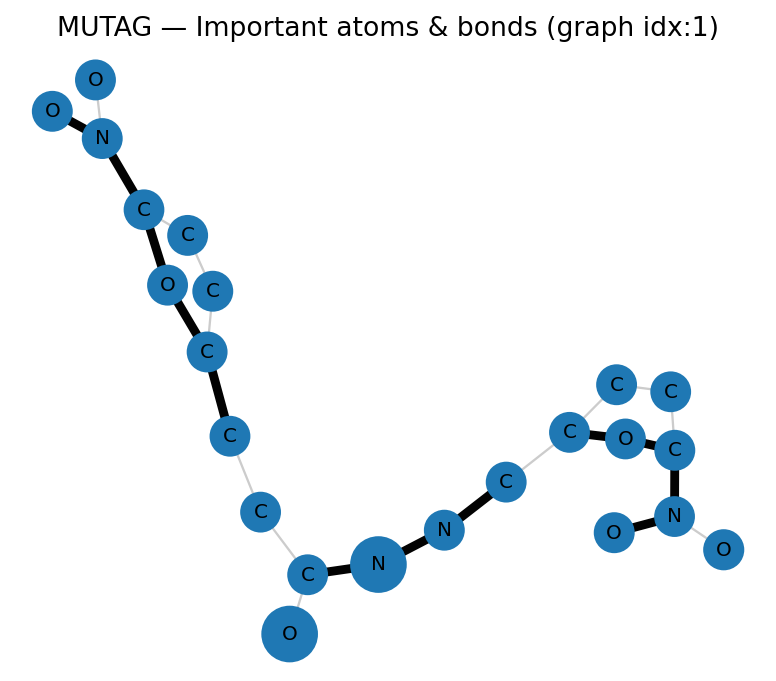

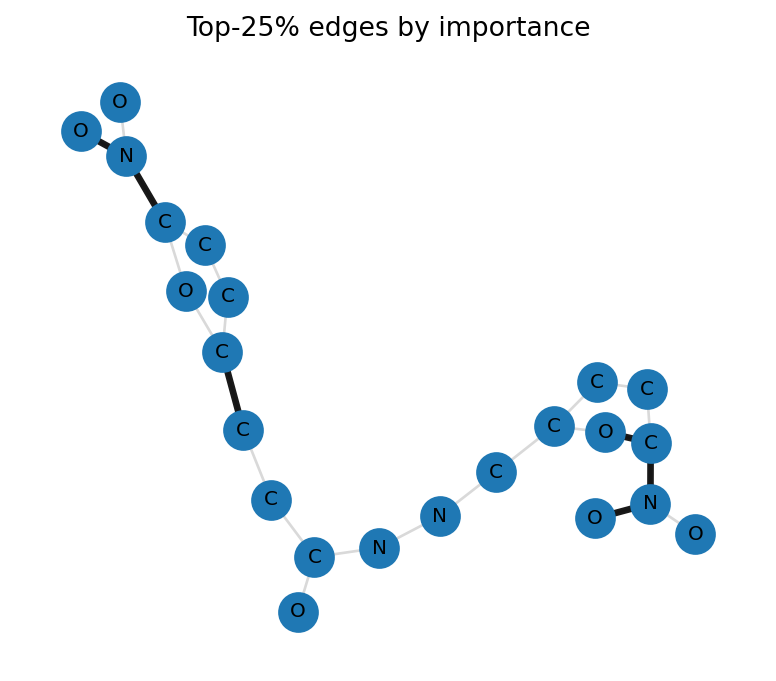

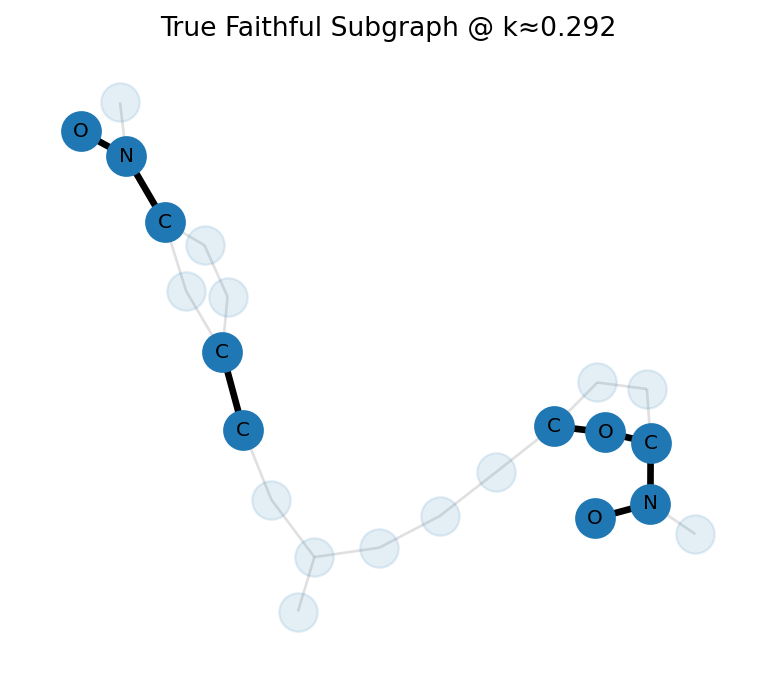

In [ ]:
# === Visualize Graph Explanations ===

# --- Full explanation: edges scaled by importance ---
visualize_explanation_graph(
    graph, edge_mask, node_mask=node_mask, pos=pos,
    title=f"MUTAG — Important atoms & bonds (graph idx:{idx})"
);

# --- Top-25% most important edges ---
visualize_topk_edges(
    graph, edge_mask, k_ratio=0.25, pos=pos,
    title="Top-25% edges by importance"
);

# --- Faithful subgraph discovery ---
visualize_faithful_subgraph(
    graph, ei_star, pos=pos,
    title=f"True Faithful Subgraph @ k≈{k_star:.3f}"
);

**Displaying Multiple Explanations**

Here we run GNNExplainer on several validation graphs and display them in a grid. This allows you to compare explanations across molecules and identify recurring mutagenic patterns.

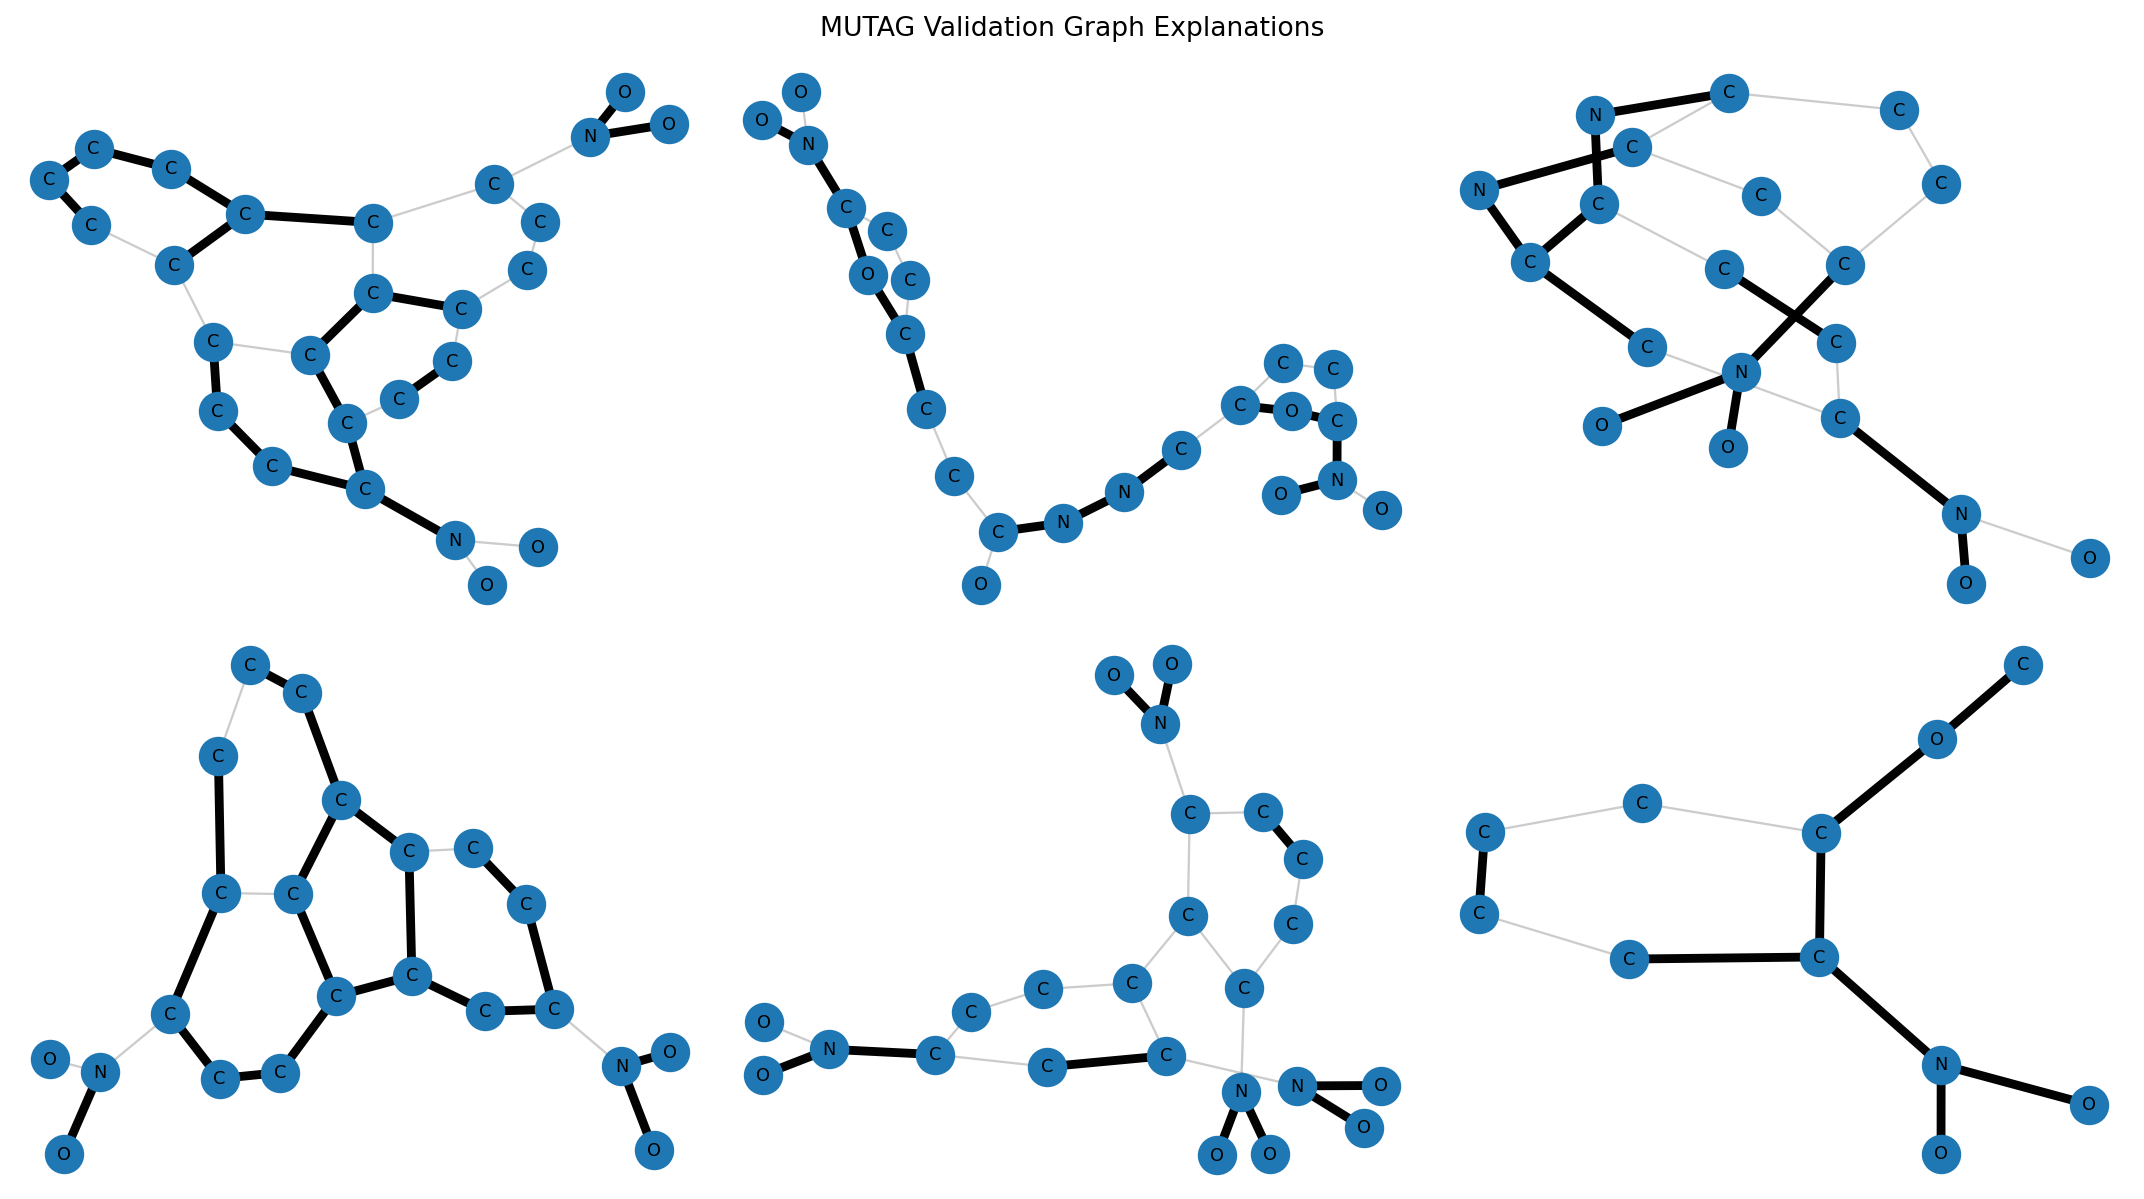

In [ ]:
# === Grid of multiple validation explanations ===
N, COLS = min(6, len(val_ds)), 3
graphs, masks = [], []

for i in range(N):

    idx_seed = i + SEED  # different but stable per index

    _, e_mask, _, _ = explain_graph(explainer, model, val_ds[i], device=device, idx_seed=idx_seed)
    graphs.append(val_ds[i].cpu()); masks.append(e_mask.cpu())

visualize_many_graphs(
    graphs, masks, cols=COLS,
    suptitle="MUTAG Validation Graph Explanations"
);

**Computing the Fidelity Curve**

This cell computes the fidelity curve for the selected graph by progressively retaining only the top-
 most important edges, as identified by the explainer, and tracking whether the model’s original prediction is preserved. The curve illustrates how prediction stability changes as structural information is removed or reintroduced.

Because prediction fidelity depends on the presence of specific critical edges or structural motifs, rather than simply the number of retained edges, the curve can exhibit non-monotonic behavior with multiple drops and rises. Removing a key edge or disrupting a supporting message-passing path may cause the prediction to change, resulting in a drop in fidelity. As
 increases, reintroducing that edge or an alternative sufficient substructure can restore the original prediction, leading to a rise in fidelity.

The minimal faithful ratio corresponds to the smallest value of
 at which the prediction is preserved, identifying the smallest subgraph that is sufficient to explain the model’s decision.

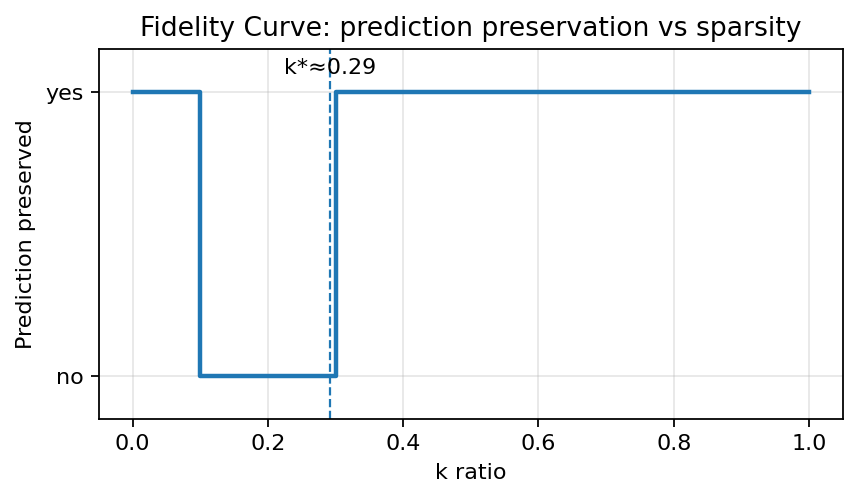

Base prediction: 0 | k* (exact) ≈ 0.292
k=0.00 | preserved=1
k=0.05 | preserved=1
k=0.10 | preserved=0
k=0.15 | preserved=0
k=0.20 | preserved=0
k=0.25 | preserved=0
k=0.30 | preserved=1
k=0.35 | preserved=1
k=0.40 | preserved=1
k=0.45 | preserved=1
k=0.50 | preserved=1
k=0.55 | preserved=1
k=0.60 | preserved=1
k=0.65 | preserved=1
k=0.70 | preserved=1
k=0.75 | preserved=1
k=0.80 | preserved=1
k=0.85 | preserved=1
k=0.90 | preserved=1
k=0.95 | preserved=1
k=1.00 | preserved=1


In [ ]:
# === Fidelity curve ===
@torch.no_grad()
def fidelity_curve_binary(model, data, edge_mask, ks=None):
    """
    Returns the base prediction on the full graph, a grid of k ratios, a binary array indicating whether
    the original prediction is preserved at each sparsity level (1 = preserved, 0 = changed), and the
    list of raw predictions corresponding to each k value.
    """

    ks = np.linspace(0.0, 1.0, 21) if ks is None else np.asarray(ks, dtype=float)

    x  = data.x.to(device)
    ei = data.edge_index.to(device)
    batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)

    base = int(model(x, ei, batch).argmax(1))
    preds = [int(model(x, to_undirected_top(ei, edge_mask, k), batch).argmax(1)) for k in ks]

    # 1 = prediction preserved, 0 = changed
    preserved = np.array([1 if p == base else 0 for p in preds], dtype=int)
    return base, ks, preserved, preds

base, ks, preserved, preds = fidelity_curve_binary(model, graph, edge_mask)

# Exact minimal k*
_, k_star_exact, _ = find_min_faithful_k(model, graph, edge_mask)

# Plot
plt.figure(figsize=(6, 3))
plt.step(ks, preserved, where="post", linewidth=2)
plt.yticks([0, 1], ["no", "yes"])
plt.ylim(-0.15, 1.15)
plt.xlabel("k ratio")
plt.ylabel("Prediction preserved")
plt.title("Fidelity Curve: prediction preservation vs sparsity")
plt.axvline(k_star_exact, linestyle="--", linewidth=1)
plt.text(k_star_exact, 1.05, f"k*≈{k_star_exact:.2f}", ha="center", va="bottom")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Base prediction: {base} | k* (exact) ≈ {k_star_exact:.3f}")
for k, b in zip(ks, preserved):
    print(f"k={k:>4.2f} | preserved={b}")


**Computing Explanation Statistics Across All Validation Graphs**

In this final analysis step, we run GNNExplainer on every validation graph and compute the minimal faithful subgraph size for each. We track predicted class, number of edges, and minimal edge set required for explanation. This provides insight into how complex or compact explanations tend to be across the entire dataset.

In [ ]:
# === All-validation ===
rows = []

for i, data in enumerate(val_ds):
    idx_seed =  i + SEED

    # One canonical explainer path
    _, e_mask, _, base_pred = explain_graph(explainer, model, data, device=device, idx_seed=idx_seed)

    # Exact minimal k*
    e_mask = e_mask.to(next(model.parameters()).device)
    _, k_star, ei_star = find_min_faithful_k(model, data, e_mask)

    # Count true (undirected) edges
    ei_np = data.edge_index.detach().cpu().numpy()
    u = np.minimum(ei_np[0], ei_np[1])
    v = np.maximum(ei_np[0], ei_np[1])
    U = len(np.unique(np.stack([u, v], axis=1), axis=0))

    rows.append({
        "index": i,
        "predicted_class": base_pred,
        "k_ratio": float(k_star),                 # minimal fraction of real edges
        "total_edges": int(U),       # real (undirected) edges
        "edges_kept": int(ei_star.size(1) // 2),  # real edges kept
    })

df_k = pd.DataFrame(rows).sort_values("index").reset_index(drop=True)
print(df_k.to_string(index=False))


 index  predicted_class  k_ratio  total_edges  edges_kept
     0                1 0.033333           30           1
     1                0 0.291667           24           7
     2                0 0.045455           22           1
     3                1 0.040000           25           1
     4                1 0.200000           25           5
     5                0 0.727273           11           8
     6                1 0.055556           18           1
     7                0 0.400000           10           4
     8                0 0.076923           13           1
     9                0 0.642857           14           9
    10                0 0.076923           13           1
    11                0 0.714286           14          10
    12                1 0.035714           28           1
    13                1 0.120000           25           3
    14                1 0.045455           22           1
    15                1 0.052632           19           1
    16        

**Conclusion**

In this lab, you explored how Graph Neural Networks learn from molecular structures and how GNNExplainer reveals the specific components of a molecule that drive a model’s prediction. After constructing and training a GCN on the MUTAG dataset, you used GNNExplainer to generate local explanations in the form of edge masks, feature masks, and minimal faithful subgraphs. These explanations highlighted chemically meaningful motifs such as NO₂ groups, NH₂ groups, and aromatic ring systems—structural patterns known to correlate with mutagenicity in nitroaromatic compounds.

By visualizing full explanations, top-k important edges, and minimal subgraphs, you gained an understanding of how a GNN makes decisions and how to evaluate the faithfulness of those explanations. The fidelity curve and dataset-wide statistics provided a quantitative view of how much information the model truly relies on when making predictions.

Overall, this lab demonstrated the value of combining graph deep learning with explainability techniques. GNNExplainer not only increases transparency and trust in GNN models but also helps verify that predictions align with established chemical knowledge. The same concepts extend to many domains where interpretability and structural reasoning are essential, including drug discovery, material science, and bioinformatics.

**References**  

- Kipf, T. N., & Welling, M. (2017). *Semi-Supervised Classification with Graph Convolutional Networks*. International Conference on Learning Representations (ICLR).  
- Ying, Z., Bourgeois, D., You, J., Zitnik, M., & Leskovec, J. (2019). *GNNExplainer: Generating Explanations for Graph Neural Networks*. Advances in Neural Information Processing Systems (NeurIPS).  
- The molecular‑graph dataset used in this lab is based on the MUTAG nitroaromatic compound benchmark from the TUDataset collection.